# Demographics and Social Science

A population report asks the same questions in the same order: what does the population look like today and what did it look like a generation ago, how have the young and the old traded places over the decades, what drove that shift, and how does the country sit among the others — who gained the most years of life, whether the world is converging, and whether income still buys longevity. This page walks one country through those questions, then widens to the world, and names the figure that answers each, so the chart to reach for arrives with the question rather than the other way round. Every figure links to the chart guide that covers it in full.

The country is **Slovenia**, and every number is real: the population by five-year age band and sex, the age-group shares, the fertility rate and the life expectancy from 1960 to 2023, then the life expectancy of every country in 1990, 2000, 2010 and 2022 and the GDP per capita and population of 198 countries in 2022, all from the World Bank's [World Development Indicators](https://datacatalog.worldbank.org/search/dataset/0037712) ([CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)). The figures are the tour a demographer's report takes; swap the country and the same cells draw it.

In [1]:
from datachart.charts import (
    DumbbellChart,
    LineChart,
    PyramidChart,
    RidgelinePlot,
    ScatterChart,
    StackedAreaChart,
)
from datachart.constants import (
    DUMBBELL_SORT_KEY,
    EMPHASIS,
    FIG_SIZE,
    LEGEND_LOCATION,
    RIDGELINE_SCALE,
    SCALE,
    SHOW_GRID,
    SORT,
    VALUE_FORMAT,
)
from datachart.utils import Grid, Panel

The hidden cell below holds the numbers. `PYRAMID` is the population of each five-year `AGE_BAND` by sex in 1960 and 2023, in thousands; `AGE_SHARES` is the share of the population under 15, of working age and 65 or over in every year since 1960; `VITALS` is the fertility rate and the life expectancy at birth per year; `LIFE_SPAN` is the life expectancy of a dozen countries in 1990 and 2022; `WORLD_LIFE` is the life expectancy of every country in four years; and `PRESTON` is the GDP per capita, life expectancy and population of 198 countries in 2022, with the World Bank region of each. The sections that follow only reshape those into the records the charts take.

In [2]:
# World Bank, World Development Indicators (CC BY 4.0), retrieved September 2026.
# Slovenia, population by five-year age band and sex (thousands)
AGE_BANDS = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']
PYRAMID = {
    1960: {
        "Men": [71.2, 75.0, 66.0, 63.0, 63.7, 66.2, 59.0, 44.5, 27.2, 43.2, 43.6, 38.7, 28.6, 18.5, 13.0, 8.7, 6.0],
        "Women": [72.3, 77.1, 68.8, 64.4, 63.8, 68.3, 67.2, 62.0, 36.2, 53.2, 52.8, 48.2, 39.9, 28.6, 22.3, 14.1, 9.4],
    },
    2023: {
        "Men": [49.4, 54.5, 58.5, 51.6, 52.1, 61.0, 67.6, 77.0, 85.4, 83.9, 76.6, 77.3, 71.9, 67.3, 56.0, 34.0, 40.5],
        "Women": [46.6, 51.8, 55.8, 49.7, 48.0, 52.4, 58.7, 68.4, 75.2, 75.5, 71.1, 75.8, 72.3, 70.9, 62.9, 44.3, 76.4],
    },
}

# Slovenia, share of the population aged 0-14, 15-64 and 65+ (%), by year
AGE_SHARES = {
    1960: (27.2, 65.2, 7.6),
    1961: (27.2, 65.1, 7.7),
    1962: (27.1, 65.1, 7.8),
    1963: (26.9, 65.1, 8.0),
    1964: (26.6, 65.2, 8.2),
    1965: (26.2, 65.3, 8.4),
    1966: (25.8, 65.4, 8.7),
    1967: (25.5, 65.5, 9.0),
    1968: (25.1, 65.7, 9.2),
    1969: (24.7, 65.9, 9.4),
    1970: (24.3, 66.1, 9.6),
    1971: (24.0, 66.2, 9.8),
    1972: (23.9, 66.1, 10.0),
    1973: (23.8, 66.0, 10.2),
    1974: (23.7, 65.9, 10.5),
    1975: (23.6, 65.8, 10.7),
    1976: (23.4, 65.7, 10.9),
    1977: (23.3, 65.6, 11.0),
    1978: (23.2, 65.6, 11.2),
    1979: (23.1, 65.6, 11.3),
    1980: (23.0, 65.8, 11.2),
    1981: (22.9, 66.1, 11.0),
    1982: (22.8, 66.5, 10.7),
    1983: (22.7, 66.9, 10.4),
    1984: (22.5, 67.3, 10.2),
    1985: (22.3, 67.6, 10.1),
    1986: (22.0, 67.9, 10.1),
    1987: (21.6, 68.3, 10.1),
    1988: (21.4, 68.3, 10.3),
    1989: (21.1, 68.4, 10.5),
    1990: (20.8, 68.5, 10.7),
    1991: (20.3, 68.8, 10.9),
    1992: (19.8, 69.0, 11.2),
    1993: (19.3, 69.1, 11.5),
    1994: (18.8, 69.3, 11.9),
    1995: (18.3, 69.5, 12.2),
    1996: (17.8, 69.6, 12.6),
    1997: (17.3, 69.7, 13.0),
    1998: (16.8, 69.8, 13.3),
    1999: (16.4, 70.0, 13.6),
    2000: (15.9, 70.1, 13.9),
    2001: (15.6, 70.2, 14.2),
    2002: (15.2, 70.3, 14.5),
    2003: (14.8, 70.4, 14.8),
    2004: (14.5, 70.5, 15.0),
    2005: (14.3, 70.4, 15.3),
    2006: (14.1, 70.3, 15.6),
    2007: (14.0, 70.2, 15.9),
    2008: (14.0, 69.9, 16.1),
    2009: (14.0, 69.7, 16.3),
    2010: (14.1, 69.5, 16.4),
    2011: (14.3, 69.2, 16.5),
    2012: (14.4, 68.8, 16.8),
    2013: (14.6, 68.3, 17.1),
    2014: (14.7, 67.7, 17.5),
    2015: (14.8, 67.2, 18.0),
    2016: (14.9, 66.6, 18.5),
    2017: (15.0, 66.0, 19.0),
    2018: (15.1, 65.5, 19.5),
    2019: (15.1, 65.0, 19.9),
    2020: (15.1, 64.7, 20.1),
    2021: (15.2, 64.4, 20.4),
    2022: (15.1, 64.0, 20.9),
    2023: (14.9, 63.7, 21.3),
}

# Slovenia, (fertility rate in births per woman, life expectancy at birth in years), by year
VITALS = {
    1960: (2.19, 69.0),
    1961: (2.27, 69.0),
    1962: (2.28, 69.0),
    1963: (2.27, 68.6),
    1964: (2.31, 68.7),
    1965: (2.43, 68.4),
    1966: (2.46, 69.0),
    1967: (2.37, 69.4),
    1968: (2.25, 68.9),
    1969: (2.17, 68.4),
    1970: (2.11, 68.6),
    1971: (2.16, 68.8),
    1972: (2.17, 69.1),
    1973: (2.2, 69.4),
    1974: (2.12, 70.2),
    1975: (2.17, 70.4),
    1976: (2.2, 70.3),
    1977: (2.17, 70.6),
    1978: (2.2, 70.7),
    1979: (2.21, 70.9),
    1980: (2.11, 71.1),
    1981: (1.96, 71.2),
    1982: (1.93, 71.1),
    1983: (1.81, 70.5),
    1984: (1.74, 70.9),
    1985: (1.71, 71.4),
    1986: (1.67, 71.8),
    1987: (1.65, 72.0),
    1988: (1.63, 72.4),
    1989: (1.52, 72.7),
    1990: (1.46, 73.2),
    1991: (1.42, 73.4),
    1992: (1.33, 73.3),
    1993: (1.33, 73.3),
    1994: (1.32, 73.4),
    1995: (1.29, 74.0),
    1996: (1.28, 74.5),
    1997: (1.25, 74.7),
    1998: (1.23, 74.8),
    1999: (1.21, 75.0),
    2000: (1.26, 75.4),
    2001: (1.21, 75.8),
    2002: (1.21, 76.0),
    2003: (1.2, 76.9),
    2004: (1.25, 77.2),
    2005: (1.26, 77.6),
    2006: (1.31, 78.1),
    2007: (1.38, 78.6),
    2008: (1.53, 78.8),
    2009: (1.53, 79.0),
    2010: (1.57, 79.4),
    2011: (1.56, 80.0),
    2012: (1.58, 80.1),
    2013: (1.55, 80.3),
    2014: (1.58, 81.1),
    2015: (1.57, 80.8),
    2016: (1.58, 81.2),
    2017: (1.62, 81.0),
    2018: (1.6, 81.4),
    2019: (1.61, 81.5),
    2020: (1.59, 80.5),
    2021: (1.64, 80.7),
    2022: (1.55, 81.3),
    2023: (1.51, 81.9),
}

# life expectancy at birth in 1990 and 2022, both sexes (years)
LIFE_SPAN = {
    'Slovenia': (73.2, 81.3),
    'Japan': (78.8, 84.0),
    'South Korea': (71.6, 82.7),
    'United States': (75.2, 77.4),
    'China': (68.2, 78.2),
    'Brazil': (65.9, 74.9),
    'Russia': (68.9, 72.5),
    'India': (58.6, 71.7),
    'South Africa': (62.9, 65.5),
    'Nigeria': (45.7, 54.1),
    'Ethiopia': (45.1, 66.9),
    'Rwanda': (47.8, 67.5),
}

# life expectancy at birth of every country with a value, by year (years); the
# Central African Republic's 2022 value, 18.8 years, is a data error and is dropped
WORLD_LIFE = {
    1990: [
        28.6, 37.6, 41.7, 41.9, 43.6, 43.7, 44.3, 45.1, 45.1, 45.1, 45.2, 45.2, 45.7, 46.5, 46.9, 46.9, 47.3, 47.6, 47.8, 48.2,
        48.5, 49.3, 49.7, 51.3, 51.4, 52.0, 52.1, 52.8, 53.0, 53.2, 54.0, 54.3, 54.6, 54.8, 55.2, 55.4, 55.5, 55.5, 55.6, 55.8,
        55.8, 56.7, 56.8, 57.1, 57.2, 57.6, 58.1, 58.3, 58.3, 58.5, 58.6, 58.8, 59.1, 59.3, 59.7, 59.8, 60.1, 60.7, 60.7, 61.0,
        61.2, 61.4, 61.6, 61.6, 61.8, 61.8, 62.0, 62.1, 62.3, 62.4, 62.5, 62.5, 62.8, 62.8, 62.9, 63.1, 63.2, 63.7, 63.9, 63.9,
        64.0, 64.1, 64.4, 65.1, 65.1, 65.2, 65.5, 65.6, 65.7, 65.8, 65.9, 66.2, 66.5, 66.7, 67.3, 67.5, 67.5, 67.6, 67.7, 67.7,
        67.8, 67.8, 67.8, 67.9, 68.1, 68.2, 68.3, 68.4, 68.7, 68.7, 68.9, 68.9, 68.9, 69.0, 69.0, 69.0, 69.1, 69.2, 69.3, 69.3,
        69.3, 69.4, 69.5, 69.5, 69.6, 69.7, 69.8, 70.0, 70.0, 70.1, 70.2, 70.4, 70.5, 70.5, 70.5, 70.6, 70.7, 70.8, 70.9, 70.9,
        70.9, 71.0, 71.0, 71.1, 71.1, 71.2, 71.2, 71.3, 71.4, 71.5, 71.6, 71.6, 71.6, 71.6, 71.7, 71.8, 72.2, 72.2, 72.4, 72.4,
        72.4, 72.5, 72.6, 72.7, 72.7, 72.8, 73.0, 73.2, 73.4, 73.4, 73.5, 73.5, 73.6, 73.7, 73.7, 73.8, 73.9, 74.0, 74.0, 74.6,
        74.8, 74.8, 74.8, 74.8, 75.1, 75.2, 75.3, 75.4, 75.6, 75.9, 76.0, 76.0, 76.1, 76.1, 76.1, 76.3, 76.4, 76.5, 76.6, 76.6,
        76.8, 76.8, 76.9, 76.9, 77.0, 77.0, 77.2, 77.4, 77.4, 77.5, 77.8, 78.0, 78.3, 78.8, 79.0, 79.4,
    ],
    2000: [
        44.8, 46.0, 46.2, 46.5, 46.6, 47.1, 47.6, 47.6, 47.6, 47.8, 47.9, 48.8, 49.2, 49.5, 49.6, 50.6, 50.6, 50.7, 50.8, 50.9,
        51.4, 51.9, 51.9, 52.3, 52.4, 52.9, 53.2, 53.3, 53.4, 54.6, 55.0, 55.4, 56.1, 56.3, 56.6, 56.7, 56.9, 57.6, 58.0, 58.1,
        58.1, 58.2, 58.3, 58.4, 58.9, 58.9, 59.5, 59.6, 60.4, 60.9, 61.0, 61.2, 61.6, 61.8, 61.8, 61.9, 62.0, 62.1, 62.6, 62.7,
        62.8, 63.2, 63.3, 63.5, 63.5, 63.8, 64.1, 64.3, 64.4, 64.5, 64.7, 64.8, 64.9, 64.9, 65.4, 65.5, 65.5, 66.2, 66.3, 66.4,
        66.8, 67.1, 67.1, 67.3, 67.5, 67.7, 67.8, 67.8, 68.1, 68.3, 68.6, 68.6, 68.6, 68.9, 68.9, 69.2, 69.6, 69.6, 69.8, 70.0,
        70.1, 70.2, 70.3, 70.3, 70.3, 70.4, 70.4, 70.5, 70.6, 70.8, 70.8, 70.9, 70.9, 70.9, 71.2, 71.2, 71.2, 71.2, 71.3, 71.3,
        71.4, 71.6, 71.7, 71.7, 71.7, 71.9, 71.9, 72.0, 72.1, 72.3, 72.4, 72.5, 72.6, 72.6, 72.6, 72.7, 72.7, 72.8, 72.8, 72.9,
        72.9, 72.9, 73.0, 73.1, 73.3, 73.4, 73.4, 73.6, 73.6, 73.7, 73.9, 73.9, 74.0, 74.0, 74.4, 74.4, 74.6, 74.7, 74.7, 74.8,
        74.8, 74.8, 74.8, 74.9, 74.9, 75.0, 75.2, 75.3, 75.4, 75.5, 75.9, 75.9, 76.2, 76.3, 76.3, 76.5, 76.6, 76.6, 76.6, 76.8,
        76.8, 77.1, 77.3, 77.5, 77.7, 77.7, 77.9, 77.9, 77.9, 77.9, 78.0, 78.0, 78.1, 78.3, 78.3, 78.4, 78.6, 78.6, 78.8, 79.0,
        79.0, 79, 79.1, 79.2, 79.2, 79.6, 79.7, 79.7, 79.8, 80.1, 80.2, 80.5, 80.9, 81.1, 81.9, 82.1,
    ],
    2010: [
        45.6, 46.0, 48.3, 48.9, 50.1, 51.3, 51.9, 51.9, 55.0, 55.3, 56.0, 56.1, 56.3, 56.4, 56.4, 56.9, 57.0, 57.0, 57.1, 57.1,
        57.2, 57.2, 57.5, 57.8, 58.3, 58.4, 58.9, 59.1, 59.4, 59.7, 60.0, 60.1, 60.7, 60.7, 60.9, 61.1, 61.2, 61.3, 61.7, 62.6,
        62.7, 62.8, 63.0, 63.1, 63.5, 63.7, 63.7, 63.7, 63.9, 64.2, 64.4, 64.5, 64.7, 64.8, 64.9, 65.7, 65.9, 66.0, 66.2, 66.8,
        66.8, 67.2, 67.2, 67.3, 68.0, 68.1, 68.3, 68.3, 68.4, 68.4, 68.5, 68.6, 68.7, 68.8, 68.8, 68.9, 69.1, 69.3, 69.3, 69.6,
        69.6, 69.8, 69.8, 69.9, 69.9, 70.2, 70.2, 70.3, 70.4, 70.7, 70.8, 70.9, 70.9, 71.3, 71.5, 71.5, 71.7, 71.7, 71.8, 71.8,
        72.0, 72.0, 72.2, 72.5, 72.6, 72.6, 72.8, 72.9, 73.0, 73.1, 73.2, 73.2, 73.3, 73.3, 73.4, 73.5, 73.5, 73.5, 73.5, 73.6,
        73.7, 73.8, 73.8, 74.1, 74.2, 74.3, 74.3, 74.4, 74.4, 74.5, 74.6, 74.7, 74.8, 74.8, 74.9, 75.0, 75.0, 75.0, 75.1, 75.1,
        75.2, 75.4, 75.4, 75.5, 75.6, 75.7, 75.7, 76.0, 76.0, 76.1, 76.1, 76.2, 76.3, 76.4, 76.5, 76.7, 76.7, 76.8, 76.8, 76.8,
        77.2, 77.4, 77.5, 77.7, 77.8, 77.9, 77.9, 78.4, 78.5, 78.6, 78.7, 78.8, 79.0, 79.1, 79.1, 79.4, 79.4, 79.4, 79.4, 79.6,
        79.9, 80.0, 80.1, 80.2, 80.4, 80.4, 80.6, 80.6, 80.6, 80.6, 80.7, 80.7, 80.9, 81.0, 81.1, 81.2, 81.3, 81.4, 81.5, 81.5,
        81.6, 81.6, 81.7, 81.7, 81.8, 81.9, 81.9, 82.0, 82.1, 82.2, 82.3, 82.8, 83.0, 83.5, 84.2, 84.6,
    ],
    2022: [
        53.9, 54.1, 54.5, 56.8, 57.2, 60.0, 60.4, 60.4, 60.5, 60.7, 61.0, 61.3, 61.6, 61.9, 61.9, 62.3, 62.4, 62.4, 62.9, 63.0,
        63.0, 63.1, 63.4, 63.5, 63.6, 63.9, 64.2, 64.2, 64.9, 65, 65.2, 65.3, 65.3, 65.5, 65.5, 65.6, 65.7, 66.0, 66.3, 66.5,
        66.5, 66.7, 66.9, 66.9, 66.9, 67.0, 67.1, 67.4, 67.4, 67.4, 67.5, 67.7, 67.7, 67.8, 67.8, 68.0, 68.3, 68.7, 68.7, 68.9,
        69.2, 69.5, 69.9, 69.9, 70.1, 70.3, 70.4, 70.5, 70.9, 71.0, 71.1, 71.2, 71.2, 71.2, 71.3, 71.5, 71.5, 71.5, 71.6, 71.7,
        71.9, 72.0, 72.0, 72.0, 72.1, 72.2, 72.3, 72.5, 72.6, 72.6, 72.7, 72.7, 72.7, 72.8, 72.8, 72.8, 72.9, 73.3, 73.3, 73.5,
        73.5, 73.6, 74.0, 74.1, 74.1, 74.1, 74.2, 74.2, 74.3, 74.3, 74.4, 74.5, 74.5, 74.5, 74.5, 74.5, 74.8, 74.9, 75.2, 75.2,
        75.2, 75.2, 75.3, 75.4, 75.6, 75.7, 75.8, 75.9, 75.9, 76.0, 76.1, 76.2, 76.2, 76.2, 76.5, 76.5, 76.6, 76.7, 76.7, 76.8,
        76.8, 76.8, 77.0, 77.1, 77.1, 77.2, 77.2, 77.3, 77.3, 77.4, 77.5, 77.6, 77.6, 77.6, 77.6, 77.7, 77.8, 77.9, 77.9, 78.0,
        78.2, 78.5, 78.8, 78.9, 79.2, 79.3, 79.3, 79.4, 80.0, 80.2, 80.3, 80.4, 80.5, 80.6, 80.6, 80.8, 80.8, 81.0, 81, 81.0,
        81.0, 81.1, 81.2, 81.3, 81.3, 81.3, 81.6, 81.6, 81.7, 81.9, 82.0, 82.1, 82.1, 82.1, 82.3, 82.5, 82.5, 82.7, 82.7, 82.7,
        82.8, 82.9, 82.9, 83.1, 83.1, 83.1, 83.2, 83.5, 83.6, 83.7, 83.9, 84.0, 84.0, 84.1, 85.7, 85.7,
    ],
}

# (country, region, GDP per capita in 2021 PPP dollars, life expectancy in years, population in millions), 2022;
# South Asia is folded into the Middle East and North Africa region, the Central African Republic is dropped
PRESTON = [
    ('Afghanistan', 'Middle East, North Africa & South Asia', 1982, 65.6, 40.58),
    ('Albania', 'Europe & Central Asia', 19389, 78.8, 2.45),
    ('Algeria', 'Middle East, North Africa & South Asia', 14782, 76.1, 45.48),
    ('Andorra', 'Europe & Central Asia', 63913, 84.0, 0.08),
    ('Angola', 'Sub-Saharan Africa', 8751, 64.2, 35.64),
    ('Antigua and Barbuda', 'Latin America & Caribbean', 27786, 77.5, 0.09),
    ('Argentina', 'Latin America & Caribbean', 27825, 75.8, 45.41),
    ('Armenia', 'Europe & Central Asia', 17886, 74.8, 2.97),
    ('Aruba', 'Latin America & Caribbean', 39083, 76.2, 0.11),
    ('Australia', 'East Asia & Pacific', 60029, 83.2, 26.02),
    ('Austria', 'Europe & Central Asia', 65694, 81.3, 9.04),
    ('Azerbaijan', 'Europe & Central Asia', 21051, 74.1, 10.14),
    ('Bahamas, The', 'Latin America & Caribbean', 34343, 74.5, 0.4),
    ('Bahrain', 'Middle East, North Africa & South Asia', 57573, 81.0, 1.52),
    ('Bangladesh', 'Middle East, North Africa & South Asia', 7888, 74.3, 169.38),
    ('Barbados', 'Latin America & Caribbean', 20495, 75.7, 0.28),
    ('Belarus', 'Europe & Central Asia', 26538, 74.1, 9.23),
    ('Belgium', 'Europe & Central Asia', 62603, 81.7, 11.68),
    ('Belize', 'Latin America & Caribbean', 12565, 72.2, 0.4),
    ('Benin', 'Sub-Saharan Africa', 3588, 60.5, 13.76),
    ('Bermuda', 'North America', 97943, 82.1, 0.06),
    ('Bhutan', 'Middle East, North Africa & South Asia', 14061, 72.8, 0.78),
    ('Bolivia', 'Latin America & Caribbean', 11488, 67.4, 12.08),
    ('Bosnia and Herzegovina', 'Europe & Central Asia', 19298, 76.8, 3.2),
    ('Botswana', 'Sub-Saharan Africa', 18647, 68.7, 2.44),
    ('Brazil', 'Latin America & Caribbean', 18554, 74.9, 210.31),
    ('Brunei Darussalam', 'East Asia & Pacific', 76358, 72.9, 0.46),
    ('Bulgaria', 'Europe & Central Asia', 32434, 74.2, 6.47),
    ('Burkina Faso', 'Sub-Saharan Africa', 2469, 60.7, 22.51),
    ('Burundi', 'Sub-Saharan Africa', 1028, 62.9, 13.32),
    ('Cabo Verde', 'Sub-Saharan Africa', 8850, 75.9, 0.52),
    ('Cambodia', 'East Asia & Pacific', 6458, 70.5, 17.2),
    ('Cameroon', 'Sub-Saharan Africa', 4844, 62.4, 27.63),
    ('Canada', 'North America', 58583, 81.1, 38.95),
    ('Cayman Islands', 'Latin America & Caribbean', 76735, 80.0, 0.07),
    ('Chad', 'Sub-Saharan Africa', 2449, 54.5, 18.46),
    ('Chile', 'Latin America & Caribbean', 29560, 79.2, 19.55),
    ('China', 'East Asia & Pacific', 21499, 78.2, 1412.17),
    ('Colombia', 'Latin America & Caribbean', 18459, 76.5, 51.74),
    ('Comoros', 'Sub-Saharan Africa', 3466, 66.5, 0.83),
    ('Congo, Dem. Rep.', 'Sub-Saharan Africa', 1484, 61.0, 102.4),
    ('Congo, Rep.', 'Sub-Saharan Africa', 6205, 65, 6.04),
    ('Costa Rica', 'Latin America & Caribbean', 25290, 79.3, 5.08),
    ("Cote d'Ivoire", 'Sub-Saharan Africa', 6272, 61.6, 30.4),
    ('Croatia', 'Europe & Central Asia', 39864, 77.6, 3.86),
    ('Curacao', 'Latin America & Caribbean', 26735, 76.7, 0.15),
    ('Cyprus', 'Europe & Central Asia', 50841, 80.4, 1.33),
    ('Czechia', 'Europe & Central Asia', 48391, 78.9, 10.67),
    ('Denmark', 'Europe & Central Asia', 69089, 81.3, 5.9),
    ('Djibouti', 'Middle East, North Africa & South Asia', 6181, 65.5, 1.14),
    ('Dominica', 'Latin America & Caribbean', 17551, 71.1, 0.07),
    ('Dominican Republic', 'Latin America & Caribbean', 22987, 74.2, 11.23),
    ('Ecuador', 'Latin America & Caribbean', 14187, 76.6, 17.82),
    ('Egypt, Arab Rep.', 'Middle East, North Africa & South Asia', 16360, 71.0, 112.62),
    ('El Salvador', 'Latin America & Caribbean', 11086, 72.0, 6.28),
    ('Equatorial Guinea', 'Sub-Saharan Africa', 16933, 63.4, 1.8),
    ('Estonia', 'Europe & Central Asia', 43125, 77.8, 1.35),
    ('Eswatini', 'Sub-Saharan Africa', 9928, 63.0, 1.22),
    ('Ethiopia', 'Sub-Saharan Africa', 2656, 66.9, 125.38),
    ('Faroe Islands', 'Europe & Central Asia', 70268, 82.8, 0.05),
    ('Fiji', 'East Asia & Pacific', 12118, 67.1, 0.92),
    ('Finland', 'Europe & Central Asia', 57068, 81.2, 5.56),
    ('France', 'Europe & Central Asia', 53674, 82.1, 68.18),
    ('Gabon', 'Sub-Saharan Africa', 18662, 67.7, 2.43),
    ('Gambia, The', 'Sub-Saharan Africa', 2863, 64.9, 2.64),
    ('Georgia', 'Europe & Central Asia', 20967, 74.1, 3.71),
    ('Germany', 'Europe & Central Asia', 63778, 80.6, 83.18),
    ('Ghana', 'Sub-Saharan Africa', 6728, 65.2, 33.15),
    ('Greece', 'Europe & Central Asia', 35828, 80.8, 10.44),
    ('Greenland', 'Europe & Central Asia', 70681, 71.2, 0.06),
    ('Grenada', 'Latin America & Caribbean', 16376, 75.2, 0.12),
    ('Guatemala', 'Latin America & Caribbean', 12144, 71.2, 17.85),
    ('Guinea', 'Sub-Saharan Africa', 3792, 60.4, 14.06),
    ('Guinea-Bissau', 'Sub-Saharan Africa', 2601, 63.6, 2.11),
    ('Guyana', 'Latin America & Caribbean', 37068, 69.9, 0.82),
    ('Haiti', 'Latin America & Caribbean', 3030, 63.9, 11.5),
    ('Honduras', 'Latin America & Caribbean', 6353, 72.7, 10.46),
    ('Hong Kong SAR, China', 'East Asia & Pacific', 64036, 83.7, 7.35),
    ('Hungary', 'Europe & Central Asia', 40611, 75.9, 9.61),
    ('Iceland', 'Europe & Central Asia', 66581, 82.1, 0.38),
    ('India', 'Middle East, North Africa & South Asia', 8347, 71.7, 1425.42),
    ('Indonesia', 'East Asia & Pacific', 13334, 70.9, 278.83),
    ('Iran, Islamic Rep.', 'Middle East, North Africa & South Asia', 16378, 76.8, 89.52),
    ('Iraq', 'Middle East, North Africa & South Asia', 13433, 72.0, 44.07),
    ('Ireland', 'Europe & Central Asia', 123007, 82.5, 5.21),
    ('Israel', 'Middle East, North Africa & South Asia', 48132, 82.7, 9.56),
    ('Italy', 'Europe & Central Asia', 52333, 82.7, 59.01),
    ('Jamaica', 'Latin America & Caribbean', 11097, 71.5, 2.84),
    ('Japan', 'East Asia & Pacific', 46819, 84.0, 125.12),
    ('Jordan', 'Middle East, North Africa & South Asia', 10158, 77.1, 11.26),
    ('Kazakhstan', 'Europe & Central Asia', 33506, 73.5, 20.03),
    ('Kenya', 'Sub-Saharan Africa', 5492, 63.5, 54.25),
    ('Kiribati', 'East Asia & Pacific', 3127, 66.3, 0.13),
    ('Korea, Rep.', 'East Asia & Pacific', 53229, 82.7, 51.67),
    ('Kosovo', 'Europe & Central Asia', 13022, 77.6, 1.77),
    ('Kuwait', 'Middle East, North Africa & South Asia', 51380, 80.6, 4.59),
    ('Kyrgyz Republic', 'Europe & Central Asia', 6140, 72.0, 6.98),
    ('Lao PDR', 'East Asia & Pacific', 8183, 68.7, 7.56),
    ('Latvia', 'Europe & Central Asia', 37719, 74.3, 1.88),
    ('Lebanon', 'Middle East, North Africa & South Asia', 11475, 78.0, 5.74),
    ('Lesotho', 'Sub-Saharan Africa', 2578, 56.8, 2.29),
    ('Liberia', 'Sub-Saharan Africa', 1579, 61.9, 5.37),
    ('Libya', 'Middle East, North Africa & South Asia', 11450, 74.5, 7.22),
    ('Lithuania', 'Europe & Central Asia', 46643, 75.6, 2.83),
    ('Luxembourg', 'Europe & Central Asia', 132571, 82.9, 0.65),
    ('Macao SAR, China', 'East Asia & Pacific', 59921, 83.1, 0.68),
    ('Madagascar', 'Sub-Saharan Africa', 1602, 63.1, 30.44),
    ('Malawi', 'Sub-Saharan Africa', 1660, 66.0, 20.57),
    ('Malaysia', 'East Asia & Pacific', 32129, 75.4, 34.7),
    ('Maldives', 'Middle East, North Africa & South Asia', 21358, 80.8, 0.52),
    ('Mali', 'Sub-Saharan Africa', 2814, 60.0, 23.07),
    ('Malta', 'Middle East, North Africa & South Asia', 56874, 82.3, 0.53),
    ('Marshall Islands', 'East Asia & Pacific', 6938, 66.7, 0.04),
    ('Mauritania', 'Sub-Saharan Africa', 6053, 68.3, 4.88),
    ('Mauritius', 'Sub-Saharan Africa', 25005, 73.5, 1.26),
    ('Mexico', 'Latin America & Caribbean', 21392, 74.0, 128.61),
    ('Micronesia, Fed. Sts.', 'East Asia & Pacific', 3816, 67.0, 0.11),
    ('Moldova', 'Europe & Central Asia', 15350, 71.5, 2.53),
    ('Mongolia', 'East Asia & Pacific', 15310, 71.9, 3.43),
    ('Montenegro', 'Europe & Central Asia', 25583, 76.2, 0.62),
    ('Morocco', 'Middle East, North Africa & South Asia', 8690, 75.2, 37.33),
    ('Mozambique', 'Sub-Saharan Africa', 1477, 63.0, 32.66),
    ('Myanmar', 'East Asia & Pacific', 5350, 66.5, 53.76),
    ('Namibia', 'Sub-Saharan Africa', 9953, 64.2, 2.89),
    ('Naoero', 'East Asia & Pacific', 12019, 61.9, 0.01),
    ('Nepal', 'Middle East, North Africa & South Asia', 4763, 70.1, 29.72),
    ('Netherlands', 'Europe & Central Asia', 71324, 81.6, 17.7),
    ('New Zealand', 'East Asia & Pacific', 49843, 82.0, 5.08),
    ('Nicaragua', 'Latin America & Caribbean', 7278, 74.5, 6.73),
    ('Niger', 'Sub-Saharan Africa', 1725, 60.4, 25.31),
    ('Nigeria', 'Sub-Saharan Africa', 7752, 54.1, 223.15),
    ('North Macedonia', 'Europe & Central Asia', 22822, 74.4, 1.83),
    ('Norway', 'Europe & Central Asia', 95110, 82.5, 5.46),
    ('Oman', 'Middle East, North Africa & South Asia', 39780, 77.9, 4.73),
    ('Pakistan', 'Middle East, North Africa & South Asia', 5526, 67.4, 243.7),
    ('Palau', 'East Asia & Pacific', 16259, 68.9, 0.02),
    ('Panama', 'Latin America & Caribbean', 33915, 79.3, 4.4),
    ('Papua New Guinea', 'East Asia & Pacific', 4126, 65.3, 10.2),
    ('Paraguay', 'Latin America & Caribbean', 15223, 72.3, 6.76),
    ('Peru', 'Latin America & Caribbean', 15567, 76.8, 33.48),
    ('Philippines', 'East Asia & Pacific', 9457, 69.5, 113.96),
    ('Poland', 'Europe & Central Asia', 43405, 77.2, 36.82),
    ('Portugal', 'Europe & Central Asia', 41071, 81.6, 10.43),
    ('Puerto Rico (US)', 'Latin America & Caribbean', 42311, 79.4, 3.22),
    ('Qatar', 'Middle East, North Africa & South Asia', 114740, 81.9, 2.66),
    ('Romania', 'Europe & Central Asia', 39257, 75.2, 19.05),
    ('Russian Federation', 'Europe & Central Asia', 38215, 72.5, 144.24),
    ('Rwanda', 'Sub-Saharan Africa', 2983, 67.5, 13.65),
    ('Samoa', 'East Asia & Pacific', 6450, 71.5, 0.22),
    ('San Marino', 'Europe & Central Asia', 70888, 85.7, 0.03),
    ('Sao Tome and Principe', 'Sub-Saharan Africa', 5632, 69.2, 0.23),
    ('Saudi Arabia', 'Middle East, North Africa & South Asia', 67179, 77.3, 32.18),
    ('Senegal', 'Sub-Saharan Africa', 4229, 67.8, 17.65),
    ('Serbia', 'Europe & Central Asia', 24652, 75.2, 6.66),
    ('Seychelles', 'Sub-Saharan Africa', 27276, 74.5, 0.12),
    ('Sierra Leone', 'Sub-Saharan Africa', 2935, 61.3, 8.28),
    ('Singapore', 'East Asia & Pacific', 134828, 82.9, 5.64),
    ('Sint Maarten (Dutch part)', 'Latin America & Caribbean', 45516, 76.2, 0.04),
    ('Slovak Republic', 'Europe & Central Asia', 38649, 77.0, 5.43),
    ('Slovenia', 'Europe & Central Asia', 47059, 81.3, 2.11),
    ('Solomon Islands', 'East Asia & Pacific', 2330, 70.4, 0.78),
    ('Somalia, Fed. Rep.', 'Sub-Saharan Africa', 1388, 53.9, 17.8),
    ('South Africa', 'Sub-Saharan Africa', 13767, 65.5, 62.38),
    ('Spain', 'Europe & Central Asia', 46733, 83.1, 47.79),
    ('Sri Lanka', 'Middle East, North Africa & South Asia', 13249, 77.3, 22.18),
    ('St. Kitts and Nevis', 'Latin America & Caribbean', 29750, 70.3, 0.05),
    ('St. Lucia', 'Latin America & Caribbean', 22811, 72.7, 0.18),
    ('St. Vincent and the Grenadines', 'Latin America & Caribbean', 16835, 71.2, 0.1),
    ('Sudan', 'Sub-Saharan Africa', 3132, 65.7, 49.38),
    ('Suriname', 'Latin America & Caribbean', 18743, 73.3, 0.62),
    ('Sweden', 'Europe & Central Asia', 62545, 83.1, 10.49),
    ('Switzerland', 'Europe & Central Asia', 85762, 83.6, 8.78),
    ('Syrian Arab Republic', 'Middle East, North Africa & South Asia', 4579, 72.8, 22.46),
    ('Tajikistan', 'Europe & Central Asia', 4214, 71.6, 10.18),
    ('Tanzania', 'Sub-Saharan Africa', 3547, 66.9, 64.71),
    ('Thailand', 'East Asia & Pacific', 20768, 75.3, 71.74),
    ('Timor-Leste', 'East Asia & Pacific', 5348, 67.4, 1.37),
    ('Togo', 'Sub-Saharan Africa', 3086, 62.3, 8.07),
    ('Tonga', 'East Asia & Pacific', 6811, 72.6, 0.11),
    ('Trinidad and Tobago', 'Latin America & Caribbean', 30784, 73.3, 1.37),
    ('Tunisia', 'Middle East, North Africa & South Asia', 12712, 76.0, 12.12),
    ('Turkiye', 'Europe & Central Asia', 33521, 77.6, 84.98),
    ('Turkmenistan', 'Europe & Central Asia', 16944, 69.9, 7.23),
    ('Turks and Caicos Islands', 'Latin America & Caribbean', 28210, 77.9, 0.05),
    ('Tuvalu', 'East Asia & Pacific', 5045, 66.9, 0.01),
    ('Uganda', 'Sub-Saharan Africa', 2725, 67.7, 47.31),
    ('Ukraine', 'Europe & Central Asia', 13787, 72.7, 41.05),
    ('United Arab Emirates', 'Middle East, North Africa & South Asia', 70076, 80.5, 10.07),
    ('United Kingdom', 'Europe & Central Asia', 53980, 81.0, 67.64),
    ('United States', 'North America', 72829, 77.4, 334.0),
    ('Uruguay', 'Latin America & Caribbean', 30840, 76.5, 3.39),
    ('Uzbekistan', 'Europe & Central Asia', 10091, 72.1, 34.94),
    ('Vanuatu', 'East Asia & Pacific', 3659, 71.3, 0.31),
    ('Viet Nam', 'East Asia & Pacific', 12980, 74.5, 99.68),
    ('Virgin Islands (U.S.)', 'Latin America & Caribbean', 46479, 80.3, 0.11),
    ('West Bank and Gaza', 'Middle East, North Africa & South Asia', 5753, 76.7, 5.04),
    ('Zambia', 'Sub-Saharan Africa', 3585, 65.3, 20.15),
    ('Zimbabwe', 'Sub-Saharan Africa', 5037, 62.4, 16.07),
]

## The age structure

### What does the population look like, and what did it look like a lifetime ago?

The first figure of a population report is the pyramid: men to the left, women to the right, one bar per age band from the youngest at the bottom to the oldest at the top. Its outline is the whole demographic history in one shape — a wide base means many births, a narrow top means few survivors, and every notch is a war, a baby boom or a wave of emigration passing through. A [pyramid chart](../../how-to-guides/charts/pyramidchart/) takes the two sides as two lists of records in the same band order, and `subtitle` names them for the legend.

One year is a snapshot; a change of shape needs two. Two pyramids drawn with the same `xmax` sit side by side in a [Grid](../../how-to-guides/utility/grid/), which takes the figures already built and redraws them into its cells, so the bars of 1960 and 2023 are on the same scale and the eye can compare bar to bar.

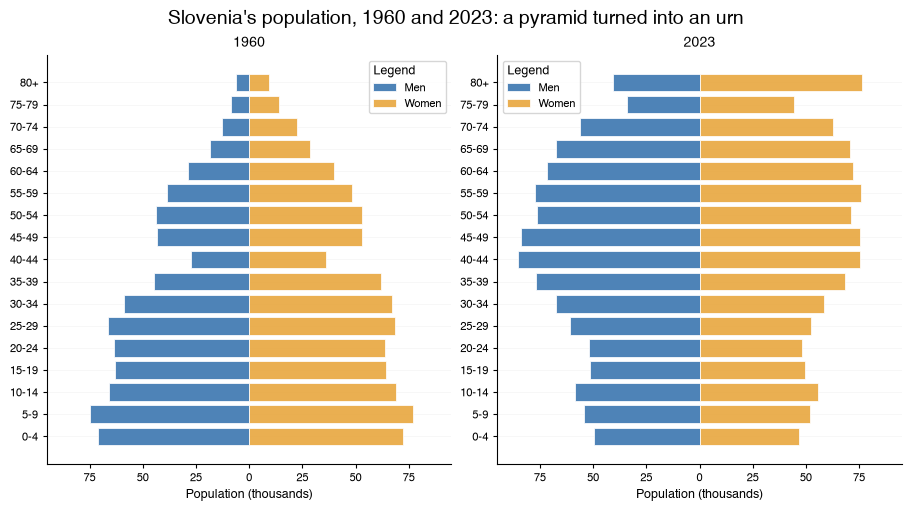

In [3]:
MEN, WOMEN = "Men", "Women"


def pyramid(year):
    return PyramidChart(
        # the two sides, youngest band first: [left, right]
        [
            [{"label": band, "y": people} for band, people in zip(AGE_BANDS, PYRAMID[year][MEN])],
            [{"label": band, "y": people} for band, people in zip(AGE_BANDS, PYRAMID[year][WOMEN])],
        ],
        subtitle=[MEN, WOMEN],
        title=str(year),
        xlabel="Population (thousands)",
        # the same span on both, so the bars compare across the years
        xmax=95,
        show_legend=True,
    )


pyramid_1960, pyramid_2023 = pyramid(1960), pyramid(2023)

Grid(
    [pyramid_1960, pyramid_2023],
    title="Slovenia's population, 1960 and 2023: a pyramid turned into an urn",
    figsize=(9.0, 5.0),
).show()

The 1960 shape is the classic pyramid, widest at the bottom and tapering steadily, with the notch at 40–44 marking the small cohorts born during the First World War. The 2023 shape is an urn: the base has narrowed to about two thirds of what it was, the widest bands are now at 40–49 and 55–59, and the 80+ band has grown from 15 thousand to 117 thousand — with women outnumbering men in it by more than two to one, which is the sex gap in longevity made visible. The population as a whole grew by a third, but every bit of that growth landed in the upper half.

### How did the young and the old trade places?

Two snapshots show the ends of the change; the shares in between show its pace, and whether it was steady or came in steps. The population splits into the under-15s, the working ages and the 65-and-overs, and three shares that sum to a hundred are a [stacked area chart](../../how-to-guides/charts/stackedareachart/): each band's thickness is its share, the bands stack to the whole, and the boundaries between them are the story. The year the oldest share overtook the youngest is the one number a report quotes from this figure, so it is a `vlines` mark with a `label`, computed from the data rather than typed in.

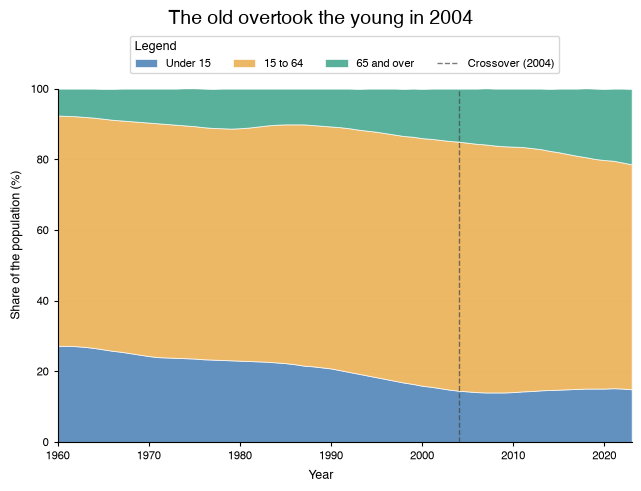

In [4]:
AGE_GROUPS = ["Under 15", "15 to 64", "65 and over"]
REFERENCE_VLINE = {"plot_vline_color": "#444444", "plot_vline_style": "--", "plot_vline_width": 1}
YEARS = sorted(AGE_SHARES)

# the first year the 65+ share exceeds the under-15 share
CROSSOVER = next(year for year in YEARS if AGE_SHARES[year][2] > AGE_SHARES[year][0])

shares_figure = StackedAreaChart(
    [
        [{"x": year, "y": AGE_SHARES[year][index]} for year in YEARS]
        for index in range(len(AGE_GROUPS))
    ],
    title=f"The old overtook the young in {CROSSOVER}",
    xlabel="Year",
    ylabel="Share of the population (%)",
    subtitle=AGE_GROUPS,
    vlines={"x": CROSSOVER, "label": f"Crossover ({CROSSOVER})", "style": REFERENCE_VLINE},
    ymax=100,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 4},
    figsize=FIG_SIZE.FULL_MEDIUM,
)
shares_figure.show()

The under-15 band thins from 27% in 1960 to 15% in 2023, and most of that loss happens in the 1980s and 1990s, when it falls fastest; the 65-and-over band grows from 8% to 21%, slowly at first and steeply after 2010 as the large post-war cohorts pass 65. The two cross in 2004. The working-age band in the middle peaked around 2000 at 70% and has been shrinking since, which is the number behind every pension debate: fewer workers per pensioner, and the trend has not turned.

### What drove the shift?

An age structure changes for two reasons and a report has to separate them: fewer births narrow the base, and longer lives widen the top. Both are yearly series, in different units, so they share the year axis but not the value axis. Two [line charts](../../how-to-guides/charts/linechart/) go into a [Panel](../../how-to-guides/utility/panel/), each assigned to its own value axis with `y_axis`, so neither flattens the other. The replacement level of 2.1 births per woman is the line the fertility rate is read against; it is an `hlines` mark with a `label` on the fertility figure, which owns the left axis.

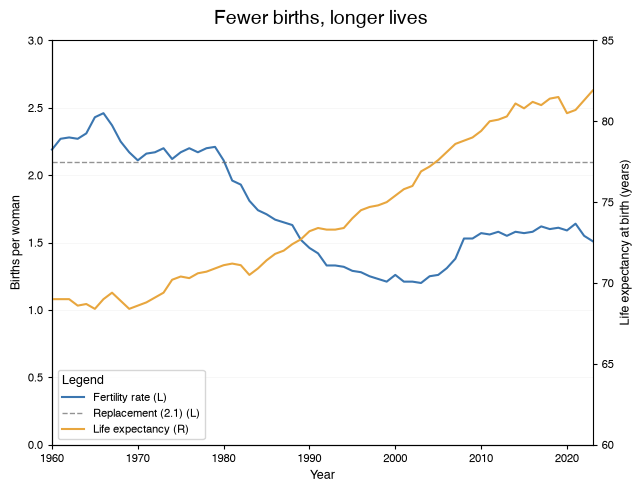

In [5]:
REPLACEMENT = 2.1
REFERENCE_HLINE = {"plot_hline_color": "#666666", "plot_hline_style": "--", "plot_hline_width": 1}

fertility = LineChart(
    [{"x": year, "y": VITALS[year][0]} for year in YEARS],
    subtitle="Fertility rate",
    hlines={"y": REPLACEMENT, "label": f"Replacement ({REPLACEMENT})", "style": REFERENCE_HLINE},
)
longevity = LineChart(
    [{"x": year, "y": VITALS[year][1]} for year in YEARS],
    subtitle="Life expectancy",
)

vitals_figure = Panel(
    [
        {"figure": fertility, "y_axis": "left"},
        {"figure": longevity, "y_axis": "right"},
    ],
    title="Fewer births, longer lives",
    xlabel="Year",
    ylabel_left="Births per woman",
    ylabel_right="Life expectancy at birth (years)",
    ymin=0,
    ymin_right=60,
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
vitals_figure.show()

The fertility rate held above replacement until 1980, then fell through it and bottomed at 1.20 in 2003; the partial recovery since has not brought it back. Life expectancy meanwhile rose from 69 to 82 years, most of it after 1990. The two curves are the two halves of the previous figure: the base narrowed when the fertility line crossed the dashed one, and the top widened as the life-expectancy line climbed. Neither is a Slovenian peculiarity, which is the reason to widen the view.

## The country among the others

### Who gained the most years since 1990?

Life expectancy in two years, for a dozen countries, is a before-and-after question, and a [dumbbell chart](../../how-to-guides/charts/dumbbellchart/) is its figure: a dot at 1990, a dot at 2022, and the connector between them is the gain. The chart sorts the rows with `sort` and `sort_by`, so the longest-lived countries sit at the top, `show_values="delta"` prints each gain at the connector, and the country of the page takes the `"highlight"` role through its record's own `emphasis`, so it stands out among its neighbours without a different chart.

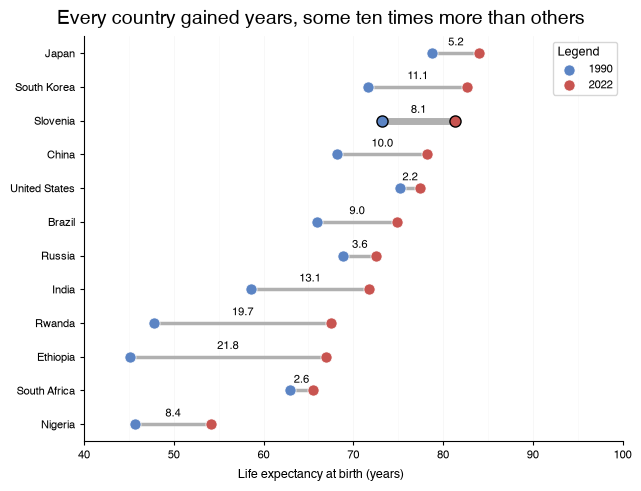

In [6]:
HOME = "Slovenia"

span_figure = DumbbellChart(
    [
        {
            "label": country,
            "start": start,
            "end": end,
            "emphasis": EMPHASIS.HIGHLIGHT if country == HOME else None,
        }
        for country, (start, end) in LIFE_SPAN.items()
    ],
    title="Every country gained years, some ten times more than others",
    xlabel="Life expectancy at birth (years)",
    start_name="1990",
    end_name="2022",
    sort=SORT.DESCENDING,
    sort_by=DUMBBELL_SORT_KEY.END,
    show_values="delta",
    value_format=VALUE_FORMAT.DECIMAL,
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
span_figure.show()

No connector points left: every country in the set lives longer than in 1990. The longest connectors belong to countries that started low — Ethiopia added 22 years, Rwanda 20 — but starting low did not guarantee catching up: Nigeria gained 8 years from the lowest start of all and South Africa, through the HIV epidemic, only 2.6. At the top the gains are small because there is less left to gain; the United States, with 2.2 years, gained least of all. Slovenia added 8 years, more than Japan and less than South Korea, which caught up with both. The mixed picture is why the next figure asks the question of every country at once.

### Is the world converging?

A dozen countries suggest convergence; the claim needs all of them. The life expectancy of every country in one year is a distribution, and four years give four distributions that a [ridgeline plot](../../how-to-guides/charts/ridgelineplot/) stacks one above the other, each a smoothed density over the countries, so a shift to the right and a narrowing are both visible at a glance. The rows are years, given as each record's `label`, and `normalize=RIDGELINE_SCALE.COMMON` draws every row to the same height, so a narrower, taller ridge means more countries clustered at one value.

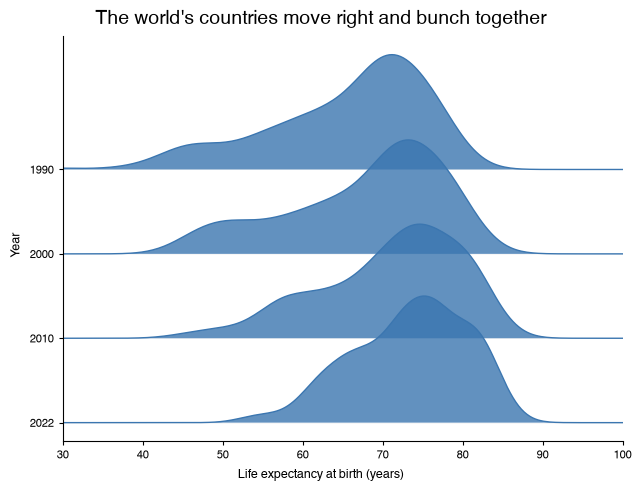

In [7]:
world_figure = RidgelinePlot(
    [
        {"label": str(year), "value": value}
        for year, values in WORLD_LIFE.items()
        for value in values
    ],
    title="The world's countries move right and bunch together",
    xlabel="Life expectancy at birth (years)",
    ylabel="Year",
    normalize=RIDGELINE_SCALE.COMMON,
    overlap=0.5,
    xmin=30,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
world_figure.show()

In 1990 the ridge is wide and has a second hump: a cluster of countries in the mid-40s below the main peak in the low 70s. Each later ridge moves right and the lower hump shrinks into the shoulder of the main one, until in 2022 the median country is at 74 years against 69 in 1990 and the middle half of the countries spans 11 years instead of 13. The world is converging, and from below: the left tail is what moved.

### Do richer countries live longer?

The classic figure of development is the Preston curve: every country as one point, GDP per capita across, life expectancy up. Income spans two orders of magnitude, so on a linear axis the poorer half of the world piles up against the left edge; `scalex=SCALE.LOG` spreads them out and turns the curve into something close to a line. The [scatter chart](../../how-to-guides/charts/scatterchart/) takes a `hue` per record to colour the points by region and a `size` to scale them by population, so a small rich country and a large poor one read differently. The country of the page gets a `texts` note with a `target`, which draws the arrow from the note to its point.

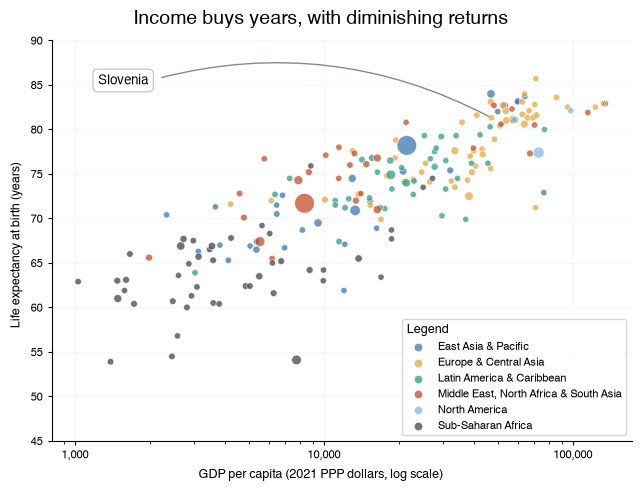

In [8]:
HOME_POINT = next(row for row in PRESTON if row[0] == HOME)

preston_figure = ScatterChart(
    [
        {"x": gdp, "y": life, "size": people, "hue": region}
        for country, region, gdp, life, people in PRESTON
    ],
    title="Income buys years, with diminishing returns",
    xlabel="GDP per capita (2021 PPP dollars, log scale)",
    ylabel="Life expectancy at birth (years)",
    scalex=SCALE.LOG,
    xticks=[1000, 10000, 100000],
    xticklabels=["1,000", "10,000", "100,000"],
    # a note on the home country, with an arrow to its point
    texts={
        "text": HOME,
        "x": 0.08,
        "y": 0.9,
        "coords": "axes",
        "target": (HOME_POINT[2], HOME_POINT[3]),
    },
    ymin=45,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.LOWER_RIGHT},
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
preston_figure.show()

The cloud rises steeply through the poorer countries and flattens past about 30,000 dollars: the same doubling of income buys many years at the bottom and almost none at the top. The correlation between log income and life expectancy is 0.85 across the 198 countries. The colours add the geography — Sub-Saharan Africa fills the lower left, Europe the upper right — and the sizes add the people: the two largest circles, India and China, sit in the middle of the band, which is where most of the world's population lives. Slovenia sits on the curve, at 47,059 dollars and 81 years, neither above nor below what its income predicts.

## The report figure

A report has room for one figure, not eight. The four that carry the argument — the shape today, how the shares shifted, who gained years, and where income puts the country — go into one panel with [Grid](../../how-to-guides/utility/grid/), which takes the figures drawn above and redraws them into its cells. Nested lists are the layout, one inner list per row, and the pyramid is the same figure that was one cell of the first grid.

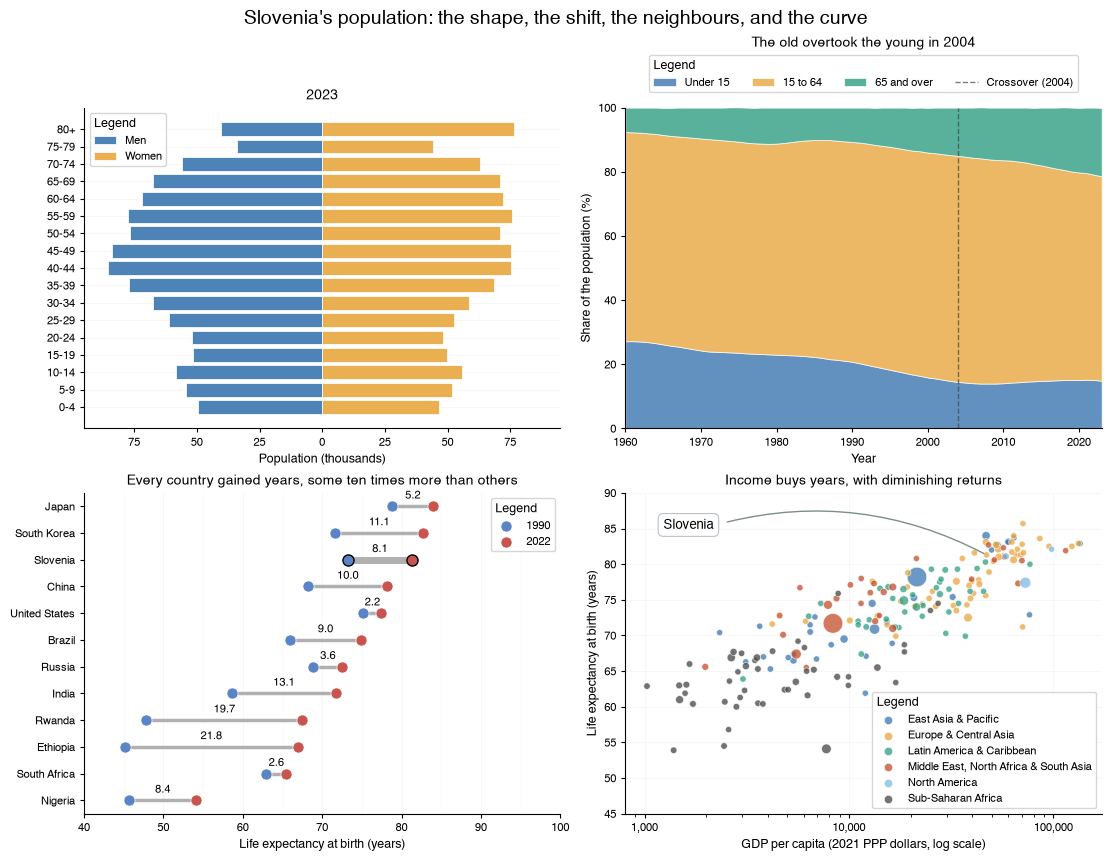

In [9]:
Grid(
    [
        [pyramid_2023, shares_figure],
        [span_figure, preston_figure],
    ],
    title="Slovenia's population: the shape, the shift, the neighbours, and the curve",
    figsize=(11.0, 8.5),
).show()

Every figure on this page is one call to a chart function over a list of dicts, and every number in them is a World Bank series reshaped by a line or two of Python written out in the cell above it. To adapt any of them, open the guide it links to and read the parameter that does the job; the [annotations guide](../../how-to-guides/utility/annotations/) covers the reference lines and notes the figures share. The charts index lists them all: [Charts](../../how-to-guides/charts/).